# Part 1 Load and Inspect the Data

In [87]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("adult-modified.csv")

### display the first 5 rows

In [88]:
df.head()

,age,workclass,education,marital-status,race,sex,hours-per-week,income
0,39,Public,13,Single,White,Male,40,<=50K
1,50,Self-emp,13,Married,White,Male,13,<=50K
2,38,Private,9,Single,White,Male,40,<=50K
3,53,Private,7,Married,Black,Male,40,<=50K
4,28,Private,13,Married,Black,Female,40,<=50K


### Report the number of rows and columns

In [89]:
df.shape

print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 10000
Columns: 8


### Display the column names and data types 

In [90]:
print(df.columns)
print(df.dtypes)

Index(['age', 'workclass', 'education', 'marital-status', 'race', 'sex',
       'hours-per-week', 'income'],
      dtype='str')
age                 str
workclass           str
education         int64
marital-status      str
race                str
sex                 str
hours-per-week    int64
income              str
dtype: object


### Summarize numeric and categorical columns

In [91]:
df.describe(include="all")

,age,workclass,education,marital-status,race,sex,hours-per-week,income
count,10000,10000,10000.000000,10000,10000,10000,10000.000000,10000
unique,72,4,NaN,2,5,2,NaN,2
top,31,Private,NaN,Single,White,Male,NaN,<=50K
freq,284,6947,NaN,5017,8556,6703,NaN,7621
mean,NaN,NaN,10.076600,NaN,NaN,NaN,40.530300,NaN
std,NaN,NaN,2.548172,NaN,NaN,NaN,12.277197,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,9.000000,NaN,NaN,NaN,40.000000,NaN
50%,NaN,NaN,10.000000,NaN,NaN,NaN,40.000000,NaN
75%,NaN,NaN,12.000000,NaN,NaN,NaN,45.000000,NaN


### What each row represents 
Each row in the dataset represnets one person with their demographic information such as age, workclass, education, marital-status, race, sex, hours-per-week and income. The target variable is income which classifies and individual as making more than or less than 50k

# Part 2: Identity Data Quality Problems

In [92]:
#sum the missing values
df.isna().sum()

age               0
workclass         0
education         0
marital-status    0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64

### Examine the unique frequency counts for 'age' and 'workclass'

In [93]:
df["age"].unique()
df["workclass"].unique()

print(df["age"].value_counts())
print(df["workclass"].value_counts())

age
31    284
35    270
34    268
23    267
33    267
     ... 
84      3
82      2
83      2
88      1
85      1
Name: count, Length: 72, dtype: int64
workclass
Private     6947
Public      1317
Self-emp    1148
?            588
Name: count, dtype: int64


### Identify values that represent missing information but are not stored as 'NaN'
Looking at the output above, we can see that in the workclass column that missing values are represented as "?" instead of "NaN". 

### Count the affected records and calculate the percentage affected in each column

In [94]:
missing_workclass = (df["workclass"] == "?").sum()

print(missing_workclass)

workclass_percent = (missing_workclass / len(df)) * 100

print(workclass_percent)

588
5.88


### Count duplicate rows

In [95]:
df.duplicated().sum()


np.int64(2601)

## Explain why equal rows rows don't prove the same person was recorded twice 
Theres no unique identifier for a person. All the values could be identical in each column for each row. So just because two people are equal in the data doesn't mean they are necesarrily a duplicate

# Part 3: Clean the data

### Replace the dataset's missing value marker with NaN

In [96]:
#make a copy of the df
df_clean = df.copy()

df_clean = df_clean.replace("?", np.nan)
#verify
df_clean.isna().sum()

age               198
workclass         588
education           0
marital-status      0
race                0
sex                 0
hours-per-week      0
income              0
dtype: int64

### Convert the age to numeric

In [97]:
df_clean["age"] = pd.to_numeric(df_clean["age"])

#verify
df_clean["age"].dtype

dtype('float64')

### Choose and apply a reasonable method for handling missing age values

In [98]:
#dropping the missing age values 

df_clean = df_clean.dropna(subset=["age"])

### Choose and apply a reasonable method for handling missing workclass values

In [99]:
#replace the missing workclass values with "unknown"
df_clean["workclass"] = df_clean["workclass"].fillna("Unknown")

### Do not automatically delete duplicate-looking rows. State and justify your decision.

The dataset does not have a unique indentifier so a row(specific person) could have all duplicate entries in each column but that does not necessarily mean that the row is a duplicate

### Verify the result by displaying data types and missing-value counts after cleaning.

In [100]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 2560


### Verify the cleaned data 

In [101]:
print(df_clean.dtypes)

print(df_clean.isna().sum())

age               float64
workclass             str
education           int64
marital-status        str
race                  str
sex                   str
hours-per-week      int64
income                str
dtype: object
age               0
workclass         0
education         0
marital-status    0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64


## Part 4: Transform the Data

### Min-Max normalize age

In [102]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean["age_normalized"] = scaler.fit_transform(
    df_clean[["age"]]
)

df_clean[["age", "age_normalized"]].head()

,age,age_normalized
0,39.0,0.301370
1,50.0,0.452055
2,38.0,0.287671
3,53.0,0.493151
4,28.0,0.150685


### Z-score standardize hours-per-week

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_clean["hours_zscore"] = scaler.fit_transform(
    df_clean[["hours-per-week"]]
)

df_clean[["hours-per-week", "hours_zscore"]].head()

,hours-per-week,hours_zscore
0,40,-0.040993
1,13,-2.241601
2,40,-0.040993
3,40,-0.040993
4,40,-0.040993


### Create 4 age groups

In [104]:
df_clean["age_group"] = pd.cut(
    df_clean["age"], 
    bins=[0, 25, 40, 60, float("inf")],
    labels=["Young Adult", "Adult", "Middle Aged", "Senior"]
)

df_clean["age_group"].value_counts()

age_group
Adult          3810
Middle Aged    3350
Young Adult    1964
Senior          678
Name: count, dtype: int64

### One-hot encode workclass and marital-status

In [105]:
predictor_shape_before = df_clean.drop(columns=["income"]).shape

df_encoded = pd.get_dummies(
    df_clean,
    columns=["workclass", "marital-status"],
    dtype=int
)

### Seperate target "income" from predictor attributes

In [106]:
x = df_encoded.drop(columns=["income"])
y = df_encoded["income"]

### Report the shape of the predictor data before and after one-hot encoding

In [107]:
print("Before one-hot encoding:", predictor_shape_before)
print("After one-hot encoding:", x.shape)

Before one-hot encoding: (9802, 10)
After one-hot encoding: (9802, 14)


# Part 5: Create and Interpret 

### Bar chart of income counts

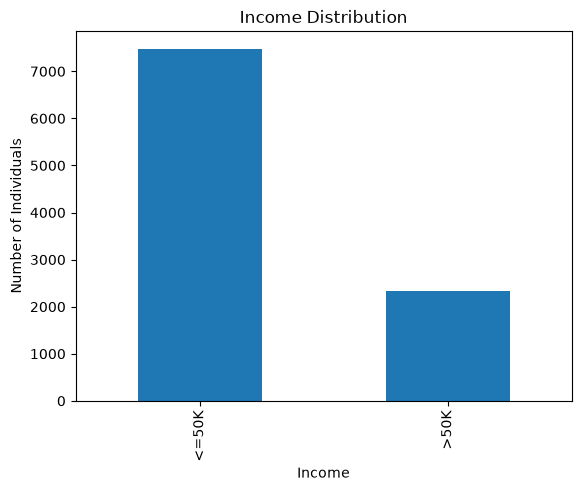

In [108]:
income_counts = df_clean["income"].value_counts()

income_counts.plot(kind="bar")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Individuals")
plt.show()


The bar chart shows the <=50k income contains more individuals than the >50k category. This shows that the income values are not balanced in the dataset as many more people under 50k are present.

### Histogram of Age

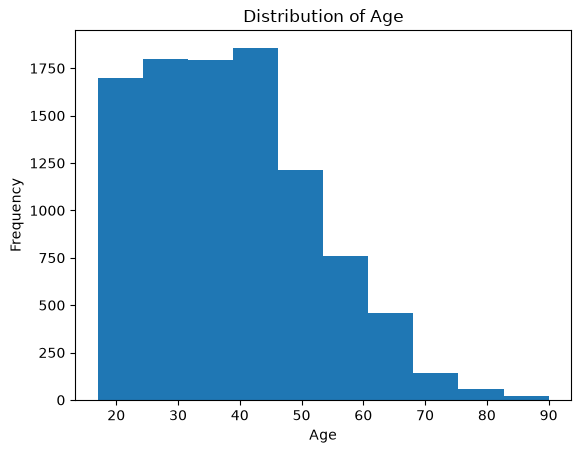

In [109]:
plt.hist(df_clean["age"], bins=10)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The graph shows a right skewed distribution as the mean lies much more torwards the middle ages like 20 through 40. This shows that a lot more of the individuals in the dataset are younger as they lie between the ages of 20 through 40 and less are in the 60 to 90 range.

### Box plot of hours per week by income

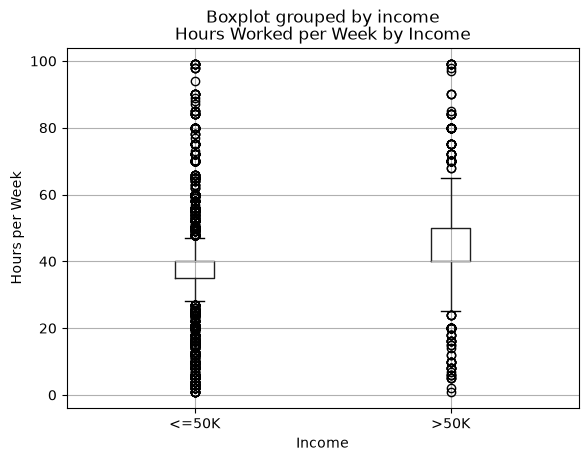

In [110]:
df_clean.boxplot(
    column="hours-per-week",
    by="income"
)

plt.title("Hours Worked per Week by Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

The graph shows that individuals that make more than 50k generally work more than people making under 50k since the median is higher for the individuals making more than 50k. Both income groups also contain many outliers under and above the range.

### High-income percentage by education level

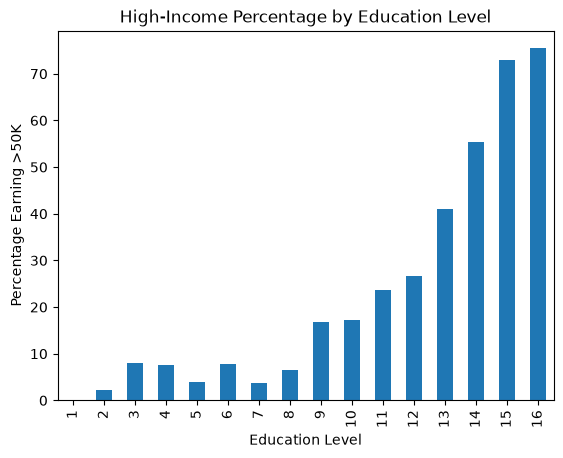

In [111]:
#get all the individuals making over 50k
df_clean["high_income"] = df_clean["income"] == ">50K"

#calculate the percentage of high income grouped on education level
high_income_percent = (
    df_clean.groupby("education")["high_income"].mean() * 100
)

high_income_percent.plot(kind="bar")

plt.title("High-Income Percentage by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage Earning >50K")
plt.show()

Looking at the graph is skewed to the left, this tells us that a higher percentage of individuals making over 50k have higher education levels. The percentage of people making over 50k as the education level increases also increases indicating people with higher education levels are more likely to make over 50k

# Export the dataset

In [112]:
df_clean.to_csv("Rotaru_Andrei_adult_clean.csv")